In [7]:
import os
print(os.listdir())

['.anaconda', '.conda', '.condarc', '.continuum', '.idlerc', '.ipynb_checkpoints', '.ipython', '.jupyter', '.matplotlib', '.ms-ad', '3D Plots.ipynb', 'anaconda3', 'anaconda_projects', 'API_SP.POP.TOTL_DS2_en_csv_v2_127039 (1).zip', 'API_SP.POP.TOTL_DS2_en_excel_v2_126989.xls', 'AppData', 'Application Data', 'Contacts', 'Cookies', 'Decision tree 03.ipynb', 'derivatives.ipynb', 'Desktop', 'Documents', 'Downloads', 'Favorites', 'gender_submission (1).csv', 'gender_submission.csv', 'Graph.ipynb', 'Links', 'Local Settings', 'Microsoft', 'miniconda3', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{2ad838bc-efea-11ee-a54d-000d3a94eaa1}.TM.blf', 'NTUSER.DAT{2ad838bc-efea-11ee-a54d-000d3a94eaa1}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{2ad838bc-efea-11ee-a54d-000d3a94eaa1}.TMContainer00000000000000000002.regtrans-ms', 'ntuser.ini', 'OneDrive', 'Pictures', 'PrintHood', 'Recent', 'Saved Games', 'Searches', 'SendTo', 'sentiment 

In [9]:
import pandas as pd

train_df = pd.read_csv('twitter_training.csv', header=None)
val_df = pd.read_csv('twitter_validation.csv', header=None)

train_df.columns = ['ID', 'Topic', 'Sentiment', 'Tweet']
val_df.columns = ['ID', 'Topic', 'Sentiment', 'Tweet']

print(train_df.head())

     ID        Topic Sentiment  \
0  2401  Borderlands  Positive   
1  2401  Borderlands  Positive   
2  2401  Borderlands  Positive   
3  2401  Borderlands  Positive   
4  2401  Borderlands  Positive   

                                               Tweet  
0  im getting on borderlands and i will murder yo...  
1  I am coming to the borders and I will kill you...  
2  im getting on borderlands and i will kill you ...  
3  im coming on borderlands and i will murder you...  
4  im getting on borderlands 2 and i will murder ...  


In [10]:
print(train_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   ID         74682 non-null  int64 
 1   Topic      74682 non-null  object
 2   Sentiment  74682 non-null  object
 3   Tweet      73996 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB
None


In [11]:
print(train_df.isnull().sum())

ID             0
Topic          0
Sentiment      0
Tweet        686
dtype: int64


In [12]:
print(train_df['Sentiment'].value_counts())

Sentiment
Negative      22542
Positive      20832
Neutral       18318
Irrelevant    12990
Name: count, dtype: int64


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

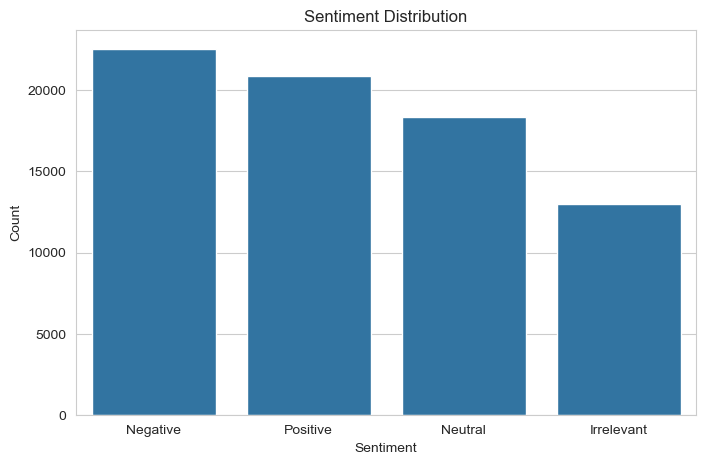

In [14]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=train_df,
    x='Sentiment',
    order=train_df['Sentiment'].value_counts().index
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

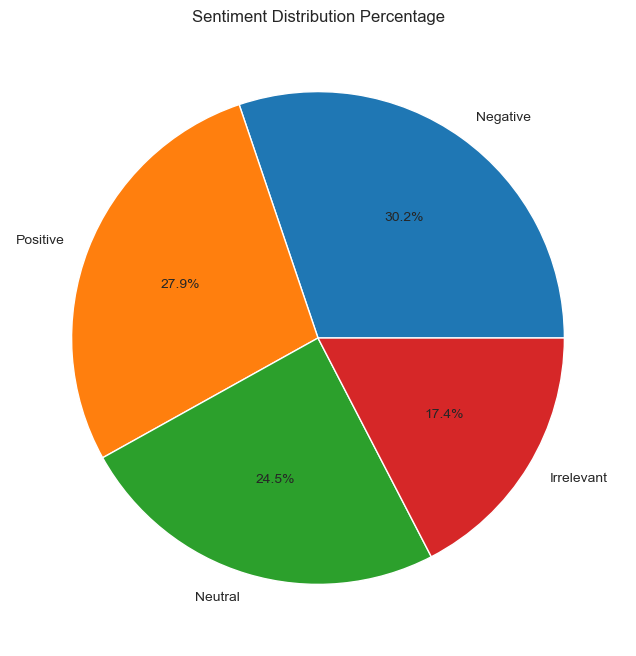

In [15]:
sentiment_counts = train_df['Sentiment'].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    sentiment_counts,
    labels=sentiment_counts.index,
    autopct='%1.1f%%'
)

plt.title("Sentiment Distribution Percentage")

plt.show()

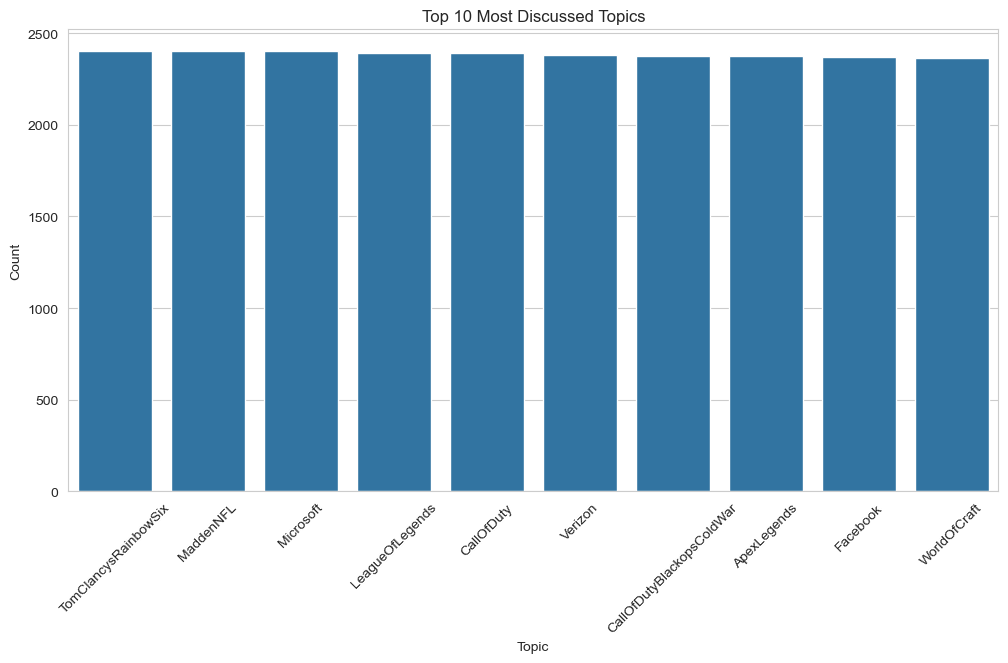

In [16]:
top_topics = train_df['Topic'].value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_topics.index,
    y=top_topics.values
)

plt.xticks(rotation=45)
plt.title("Top 10 Most Discussed Topics")
plt.xlabel("Topic")
plt.ylabel("Count")

plt.show()

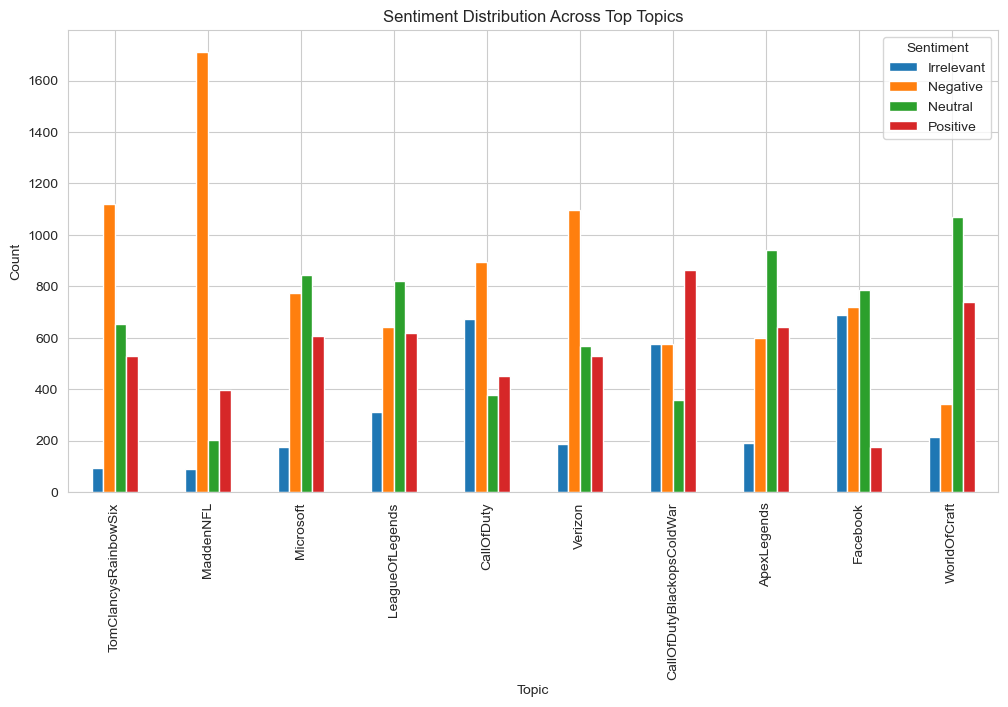

In [17]:
topic_sentiment = pd.crosstab(
    train_df['Topic'],
    train_df['Sentiment']
)

top10 = train_df['Topic'].value_counts().head(10).index

topic_sentiment.loc[top10].plot(
    kind='bar',
    figsize=(12,6)
)

plt.title("Sentiment Distribution Across Top Topics")
plt.xlabel("Topic")
plt.ylabel("Count")

plt.show()

In [18]:
!pip install wordcloud

   ---------------------------------------- 0.0/307.2 kB ? eta -:--:--
   ---------------------------------------- 0.0/307.2 kB ? eta -:--:--
   - -------------------------------------- 10.2/307.2 kB ? eta -:--:--
   - -------------------------------------- 10.2/307.2 kB ? eta -:--:--
   --- ----------------------------------- 30.7/307.2 kB 217.9 kB/s eta 0:00:02
   ------- ------------------------------- 61.4/307.2 kB 297.7 kB/s eta 0:00:01
   ------------- ------------------------ 112.6/307.2 kB 467.6 kB/s eta 0:00:01
   --------------------- ---------------- 174.1/307.2 kB 615.9 kB/s eta 0:00:01
   ------------------------------- ------ 256.0/307.2 kB 827.5 kB/s eta 0:00:01
   -------------------------------------- 307.2/307.2 kB 827.2 kB/s eta 0:00:00


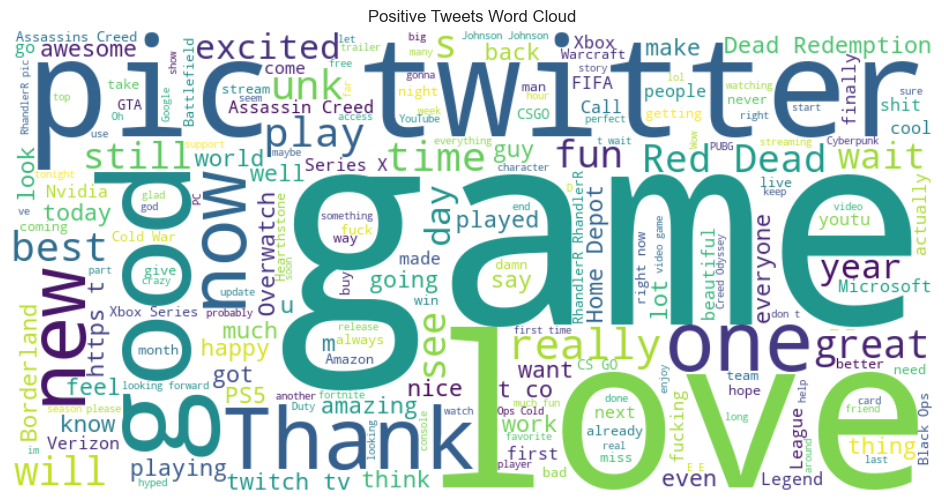

In [19]:
from wordcloud import WordCloud

positive_text = " ".join(
    train_df[train_df['Sentiment']=='Positive']['Tweet'].astype(str)
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(positive_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Positive Tweets Word Cloud")

plt.show()

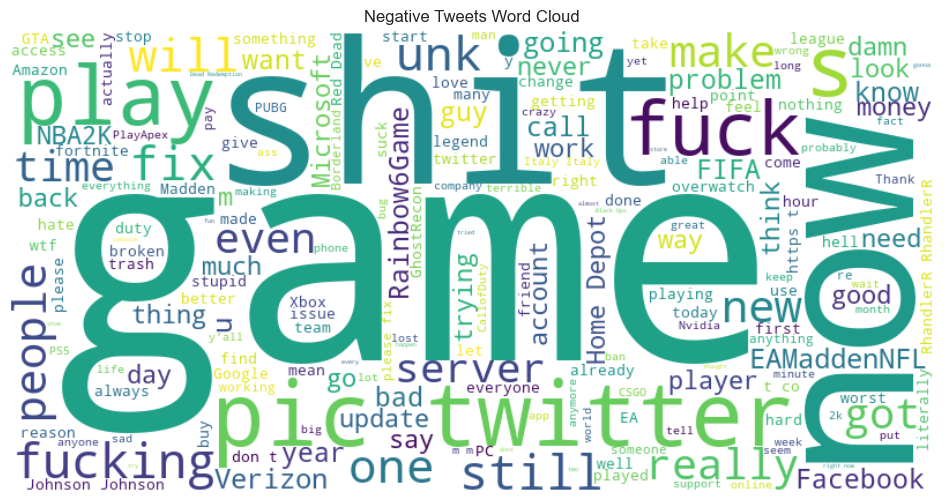

In [20]:
negative_text = " ".join(
    train_df[train_df['Sentiment']=='Negative']['Tweet'].astype(str)
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(negative_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Negative Tweets Word Cloud")

plt.show()